# HDFS 에서 파일 읽어오기

In [1]:
# !pip install hdfs

In [2]:
!hostname -I

172.17.0.2 172.21.0.6 


In [8]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt 

Text(0.2, 0.4, '한글')

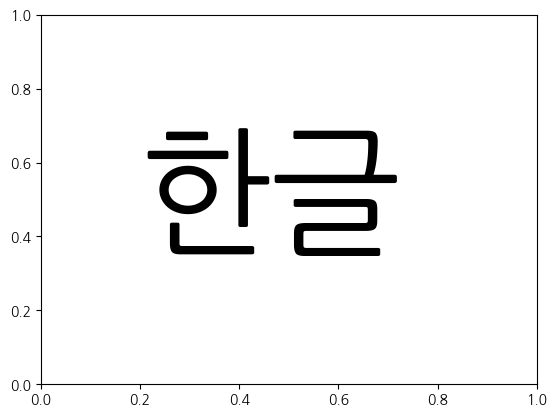

In [11]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [9]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path = "/dataset/행정구역시도성연령별취업자20260609.csv"

with client_hdfs.read(path, encoding='euc-kr') as reader:
    data = pd.read_csv(reader)

data.columns = ['year', 'region', 'gender', 'age', 'value']

styled_data = data.head(10).style.set_table_styles([
    {'selector':'th,td','props':[
        ('text-align','center'),
        ('border','1px solid #ccc')
    ]}
])
styled_data


,year,region,gender,age,value
0,2015.1/4,서울특별시,남자,20 - 29세,322
1,2015.1/4,서울특별시,남자,30 - 39세,752
2,2015.1/4,서울특별시,남자,40 - 49세,750
3,2015.1/4,서울특별시,남자,50 - 59세,669
4,2015.1/4,서울특별시,남자,60세이상,366
5,2015.1/4,서울특별시,여자,20 - 29세,468
6,2015.1/4,서울특별시,여자,30 - 39세,509
7,2015.1/4,서울특별시,여자,40 - 49세,513
8,2015.1/4,서울특별시,여자,50 - 59세,502
9,2015.1/4,서울특별시,여자,60세이상,244


In [10]:
data2 = data.copy()
data2['value'] = pd.to_numeric(data2['value'], errors='coerce')
data2.dtypes

year       object
region     object
gender     object
age        object
value     float64
dtype: object

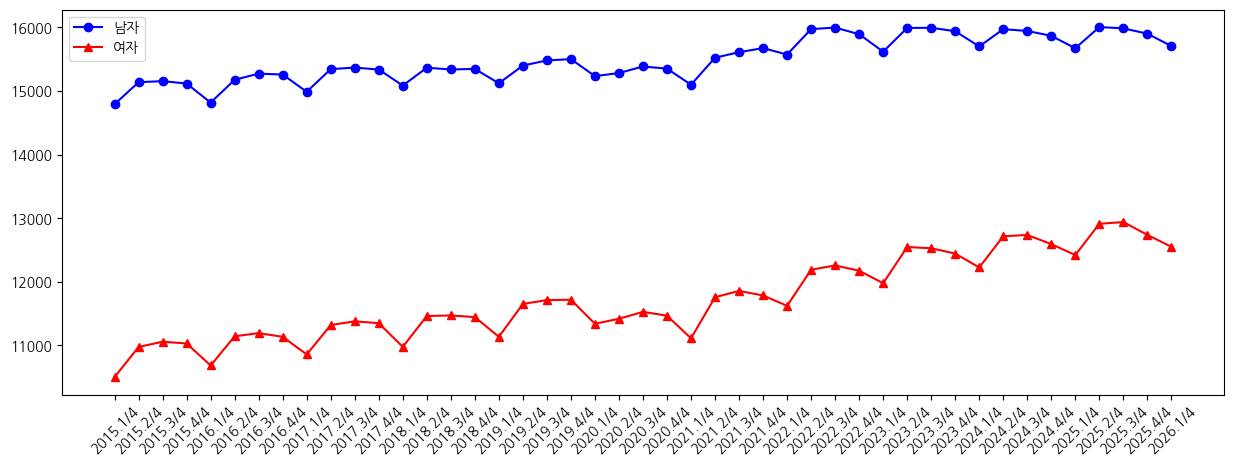

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (중요!)
plt.rc('font', family='NanumGothic') 

# 데이터 로드 및 가공
data = pd.read_csv("/home/jovyan/work/dataset/행정구역시도성연령별취업자202606.csv", encoding='euc-kr')
data.columns = ['year', 'region', 'gender', 'age', 'value']
data2 = data.copy()
data2['value'] = pd.to_numeric(data2['value'], errors='coerce')

# 데이터 그룹화
data3 = data2.groupby(['year','gender'])['value'].sum().reset_index(name='total')
male = data3[data3['gender'] == '남자']
female = data3[data3['gender'] == '여자']

# 시각화
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(male['year'], male['total'], label='남자', color='blue', linestyle='-', marker='o')
ax.plot(female['year'], female['total'], label='여자', color='red', linestyle='-', marker='^')

# 2. 눈금 위치 지정 후 라벨 설정 (경고 방지)
ax.set_xticks(range(len(male['year'])))
ax.set_xticklabels(male['year'], rotation=45)

ax.legend()
plt.show()

## 전국 청년과 60대 이상 취업자수 관계

In [21]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt 

In [28]:
clinet_hdfs = InsecureClient('httpL//namenode:9870',user='hadoop')
path = "/dataset/행정구역시도성연령별취업자202606.csv"


In [40]:
# 1. 먼저 컬럼명을 영어로 변경합니다.
data.columns = ['year', 'region', 'gender', 'age', 'value']

# 2. 그 다음, 변경된 컬럼명을 사용하여 연산(숫자 변환 등)을 수행합니다.
data['value'] = pd.to_numeric(data['value'], errors='coerce').fillna(0).astype(int)

# 3. 이제 필터링을 시도합니다.
mydata = data[data['year'] >= "2025.1/4"]

# 4. 결과 확인
print(mydata.head())
print(data.dtypes)

          year region gender       age  value
6800  2025.1/4  서울특별시     남자  20 - 29세    323
6801  2025.1/4  서울특별시     남자  30 - 39세    652
6802  2025.1/4  서울특별시     남자  40 - 49세    595
6803  2025.1/4  서울특별시     남자  50 - 59세    604
6804  2025.1/4  서울특별시     남자     60세이상    529
year      object
region    object
gender    object
age       object
value      int64
dtype: object


In [41]:
# 1. 실제 컬럼 이름 확인
print("현재 컬럼 이름:", data.columns.tolist())

# 2. 만약 공백이 있다면 공백 제거
data.columns = [c.strip() for c in data.columns]

# 3. 이제 다시 시도
mydata = data[data['year'] >= "2025.1/4"]

현재 컬럼 이름: ['year', 'region', 'gender', 'age', 'value']


In [42]:
mydata = data[data['year'] >= "2025.1/4"]

In [49]:
mydata['age']

6800    20 - 29세
6801    30 - 39세
6802    40 - 49세
6803    50 - 59세
6804       60세이상
          ...   
7645    20 - 29세
7646    30 - 39세
7647    40 - 49세
7648    50 - 59세
7649       60세이상
Name: age, Length: 850, dtype: object

In [51]:
x_data = mydata[mydata['age'].isin(['20 - 29세'])]
y_data = mydata[mydata['age'].isin(['60세이상'])]
z_data = mydata

In [68]:
# 1. isin()에 리스트 형태(대괄호 사용)로 값을 전달
x_data = mydata[mydata['age'].isin(['20 - 29세'])]
y_data = mydata[mydata['age'].isin(['60세이상'])]
z_data = mydata

# 2. 'city' 대신 컬럼명인 'region'으로 그룹화 수행
xx = x_data.groupby('region')['value'].sum() #.reset_index(name="total") # 20대 취업자
yy = y_data.groupby('region')['value'].sum() #.reset_index(name="total") # 60대(정년퇴임) 취업자
zz = z_data.groupby('region')['value'].sum() #.reset_index(name="total") # 전체 취업자

# 결과 확인
# print(xx.head())
xx

region
강원도         421
경기도        4780
경상남도        780
경상북도        718
광주광역시       434
대구광역시       656
대전광역시       560
부산광역시      1002
서울특별시      3833
세종특별자치시     104
울산광역시       310
인천광역시       981
전라남도        451
전라북도        472
제주도         206
충청남도        758
충청북도        581
Name: value, dtype: int64

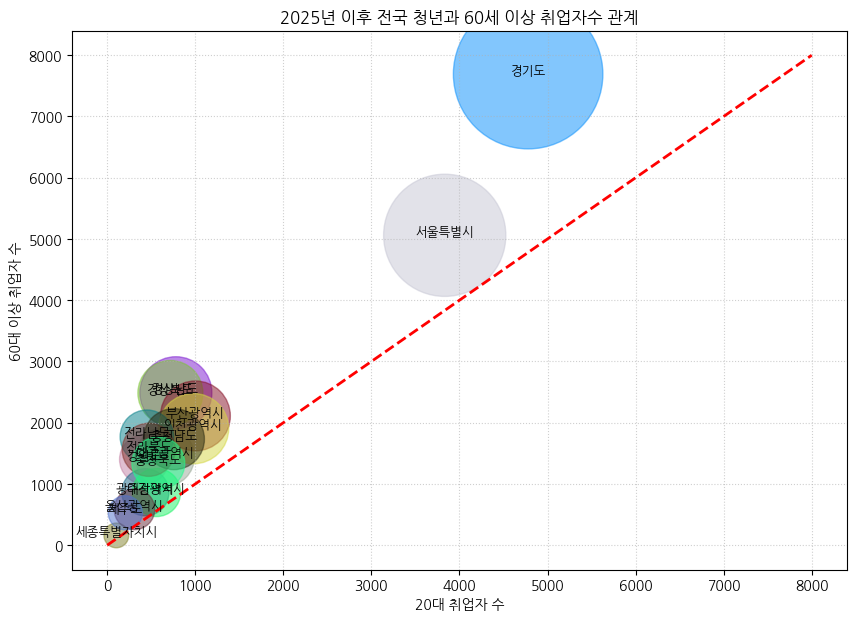

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# 폰트 설정 (이미 되어 있다면 생략 가능)
plt.rc('font', family='NanumGothic')

# 1. 그룹화 (데이터는 이전 단계에서 정의된 x_data, y_data, z_data 사용)
xx = x_data.groupby('region')['value'].sum().reset_index(name="total")
yy = y_data.groupby('region')['value'].sum().reset_index(name="total")
zz = z_data.groupby('region')['value'].sum().reset_index(name="total")

# 색상 랜덤 생성 (데이터 개수만큼)
colors = [np.random.rand(3,) for _ in range(len(xx))]

# 2. 시각화
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(xx['total'], yy['total'], s=zz['total'] * 0.3, c=colors, alpha=0.5)

# 3. 각 점에 지역 이름 표시
for i in range(len(xx)):
    ax.annotate(
        xx['region'][i],                     # 지역 이름 컬럼 사용
        xy=(xx['total'][i], yy['total'][i]), # x, y 좌표
        ha='center',                         # 가로 정렬
        fontsize=9                           # 글자 크기 조정
    )

ax.plot([0, 8000], [0, 8000], color='r', linestyle='--', linewidth=2)

ax.set_title('2025년 이후 전국 청년과 60세 이상 취업자수 관계')
ax.set_xlabel('20대 취업자 수')
ax.set_ylabel('60대 이상 취업자 수')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 인사이트 : 